# 01 — Data Exploration

Goal: Pull S&P 500 ticker list, fetch 5 years of OHLCV data for a few test stocks, and sanity-check the data.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## 1. S&P 500 Ticker List

Pull the current S&P 500 constituents from Wikipedia.

In [2]:
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "StockPredictor/1.0 (bachelor thesis project)"}
response = requests.get(url, headers=headers)

sp500_table = pd.read_html(StringIO(response.text))[0]
sp500_tickers = sp500_table["Symbol"].str.replace(".", "-", regex=False).tolist()

print(f"Total S&P 500 tickers: {len(sp500_tickers)}")
print(f"First 10: {sp500_tickers[:10]}")
sp500_table[["Symbol", "Security", "GICS Sector"]].head(10)

Total S&P 500 tickers: 503
First 10: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


,Symbol,Security,GICS Sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology
5,ADBE,Adobe Inc.,Information Technology
6,AMD,Advanced Micro Devices,Information Technology
7,AES,AES Corporation,Utilities
8,AFL,Aflac,Financials
9,A,Agilent Technologies,Health Care


## 2. Fetch 5 Years of OHLCV Data

Test with a diverse set of stocks across sectors before scaling to the full S&P 500.

## 3. Sanity Checks

Check for missing values, gaps in dates, and basic statistics.

In [4]:
for ticker in test_tickers:
    df = data[ticker].dropna(how="all")
    missing = df.isnull().sum()
    print(f"\n--- {ticker} ---")
    print(f"  Rows: {len(df)}")
    print(f"  Date range: {df.index.min().date()} to {df.index.max().date()}")
    print(f"  Missing values:\n{missing[missing > 0].to_string() if missing.any() else '    None'}")


--- AAPL ---
  Rows: 1255
  Date range: 2021-03-24 to 2026-03-23
  Missing values:
    None

--- MSFT ---
  Rows: 1255
  Date range: 2021-03-24 to 2026-03-23
  Missing values:
    None

--- JPM ---
  Rows: 1255
  Date range: 2021-03-24 to 2026-03-23
  Missing values:
    None

--- JNJ ---
  Rows: 1255
  Date range: 2021-03-24 to 2026-03-23
  Missing values:
    None

--- XOM ---
  Rows: 1255
  Date range: 2021-03-24 to 2026-03-23
  Missing values:
    None


In [5]:
# Basic price statistics per ticker
for ticker in test_tickers:
    df = data[ticker].dropna(how="all")
    print(f"\n--- {ticker} ---")
    print(df[["Open", "High", "Low", "Close", "Volume"]].describe().round(2).to_string())


--- AAPL ---
Price     Open     High      Low    Close        Volume
count  1255.00  1255.00  1255.00  1255.00  1.255000e+03
mean    185.13   187.13   183.32   185.31  6.703875e+07
std      41.71    42.00    41.37    41.68  2.834728e+07
min     116.43   117.27   115.77   116.78  1.791060e+07
25%     149.25   151.24   147.68   149.39  4.715335e+07
50%     175.33   177.07   173.90   175.51  6.027330e+07
75%     219.45   221.86   216.62   219.80  8.034650e+07
max     285.93   288.35   283.04   285.92  3.186799e+08

--- MSFT ---
Price     Open     High      Low    Close        Volume
count  1255.00  1255.00  1255.00  1255.00  1.255000e+03
mean    350.75   353.95   347.34   350.77  2.577780e+07
std      87.22    87.46    86.70    87.07  1.065810e+07
min     211.39   214.17   207.39   208.18  5.855900e+06
25%     273.75   276.80   270.13   273.70  1.894115e+07
50%     329.53   332.38   326.80   330.12  2.327770e+07
75%     416.79   420.01   412.46   415.99  2.954065e+07
max     552.02   552

## 4. Price Charts

Visualize closing prices to verify data looks correct.

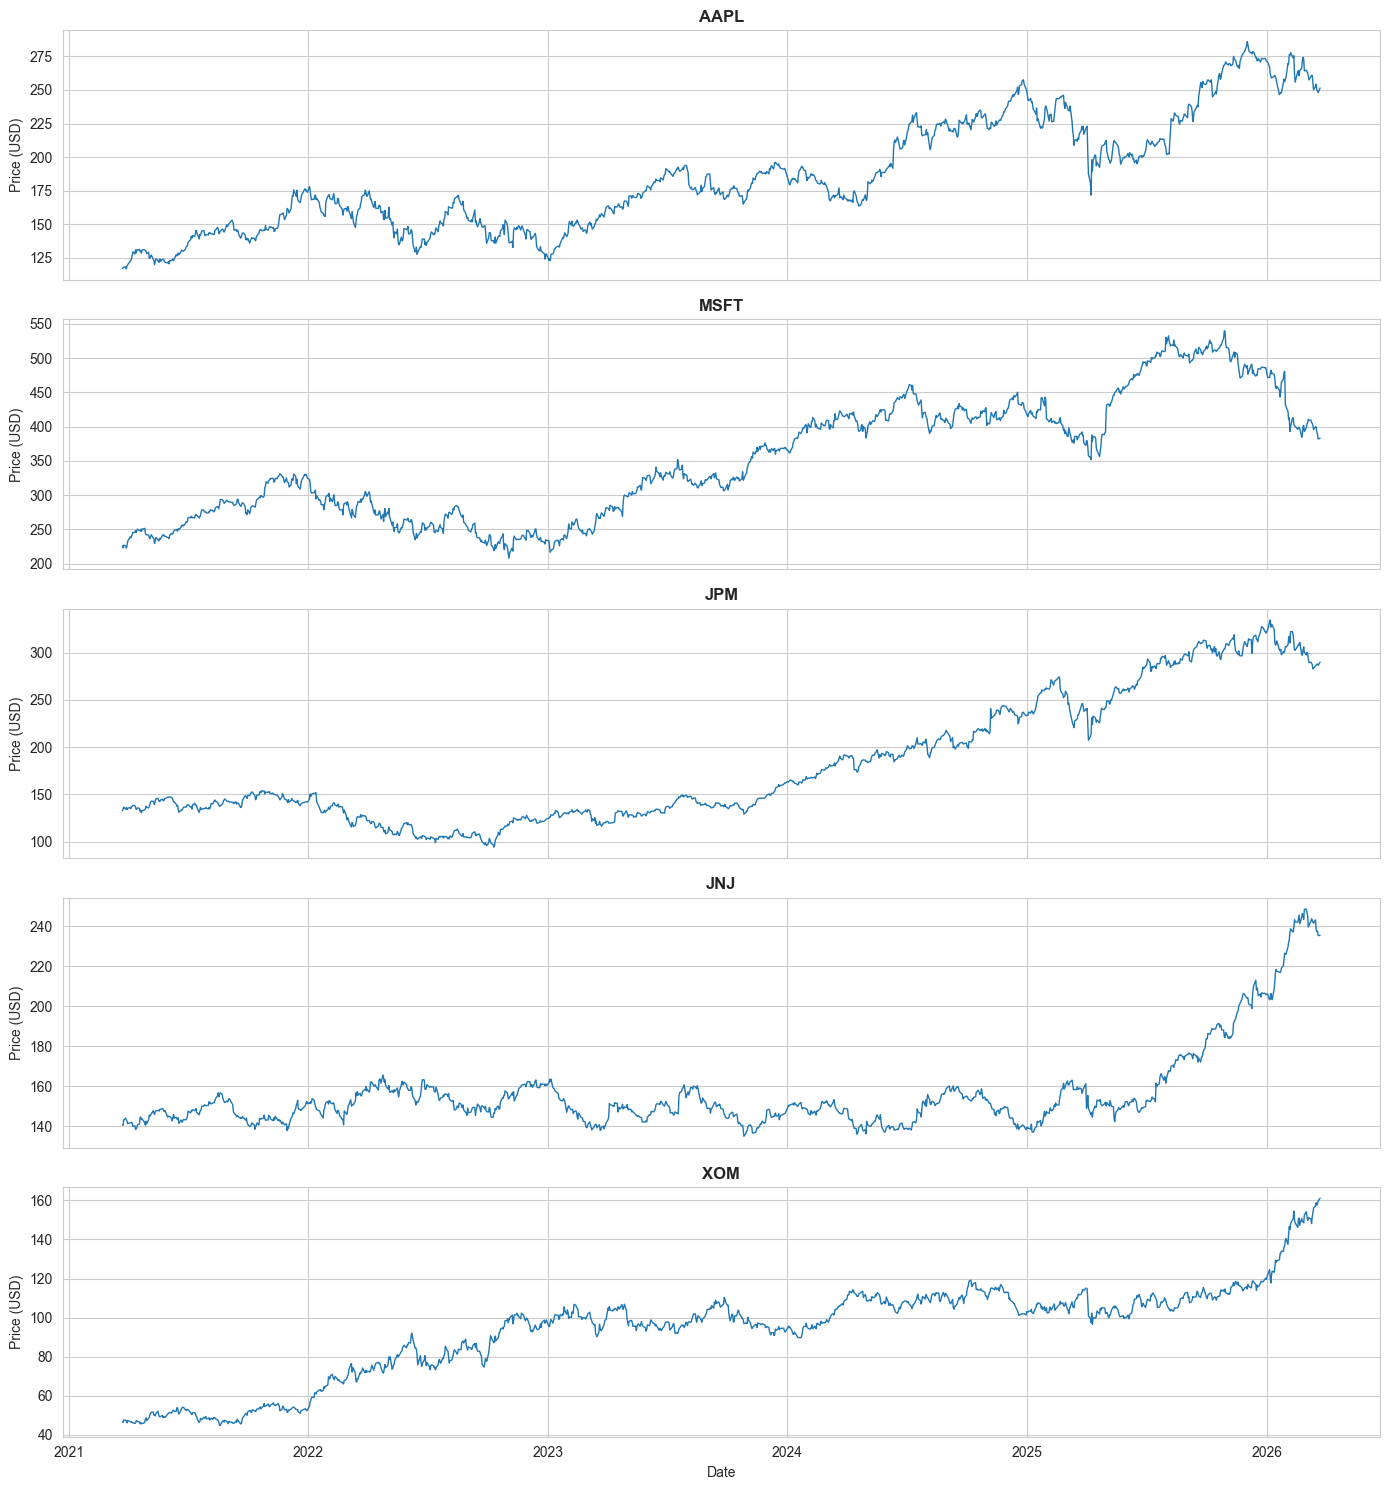

In [6]:
fig, axes = plt.subplots(len(test_tickers), 1, figsize=(14, 3 * len(test_tickers)), sharex=True)

for i, ticker in enumerate(test_tickers):
    close = data[ticker]["Close"].dropna()
    axes[i].plot(close.index, close.values, linewidth=1)
    axes[i].set_title(ticker, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Price (USD)")

plt.xlabel("Date")
plt.tight_layout()
plt.show()